In [1]:
import os
import sys
import pickle
import numpy as np
from numba import njit
import itertools as itt
import aerosandbox as asb

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from Aircraft.Planform import Planform
from Aircraft.Fixed import Fixed
from Drag.Fuselage import Fuselage
from Drag.Bay import Bay
from Drag.LandingGear import LandingGear
from Aircraft.Aircraft import Aircraft
from global_parameters import Assumptions
from Requirements.FuelReq import FuelReq
from Requirements.LGReq import LGReq
from Requirements.MassReq import MassReq
from Requirements.MDReq import MDReq
from Requirements.EmpennageReq import EmpennageReq
from Requirements.Requirement import Requirement
from EmpennageSizing.TailFinder import TailFinder
from EmpennageSizing.CanardFinder import CanardFinder
from structural_analysis.Material import Material

# Loading the pre-computed planforms and the fuselage

In [2]:
with open("pickles/planform_pickle_official.pcl", "r+b") as f:
    plaforms_recovered:list[tuple[Planform, str, bool]] = pickle.load(f)

assumptions = Assumptions()

In [3]:
# --- Import Onshape pull utilities ---
sys.path.append(os.path.abspath(os.getcwd()))
from onshape_pull import (
    fetch_variable_studio, fetch_measurement_features,
    evaluate_measurements, load_cached_masses, fetch_mass_properties,
    compute_cg_scenarios, lookup_var, lookup_meas,
    UPDATE_MASSES,
)

# --- Pull data from Onshape ---
variables = fetch_variable_studio()
meas_names = fetch_measurement_features()
measurements = evaluate_measurements(meas_names)
components = load_cached_masses() if not UPDATE_MASSES else fetch_mass_properties()
cg_data = compute_cg_scenarios(components)

# --- Z offset (axle datum) ---
Front_Landing_Gear_Hinge_Z = lookup_meas(measurements, "Front_Landing_Gear_Hinge_Z")
Front_Strut_Height, _, _ = lookup_var(variables, "Front_Strut_Height")
Front_Gear_Extension_Max = lookup_meas(measurements, "Front_Gear_Extension_Max")
Front_Gear_Extension_Min = lookup_meas(measurements, "Front_Gear_Extension_Min")
z_offset = (Front_Landing_Gear_Hinge_Z + Front_Strut_Height
            + (Front_Gear_Extension_Max - Front_Gear_Extension_Min))

# --- Build drag components ---
engine_bay = Bay(
    surface_wetted=83744.32631 / 1e6,  # mm² → m² (hardcoded, not in Onshape)
    length=0.172,                       # 172 mm (hardcoded, not in Onshape)
    diameter=lookup_var(variables, "engine_diameter")[0],
)

Front_Gear_Unexposed = lookup_meas(measurements, "Front_Gear_Unexposed")
nose_gear = LandingGear(
    wheel_width=0.025,
    exposed_height=Front_Strut_Height - Front_Gear_Unexposed,
    wheel_diameter=lookup_var(variables, "Wheel_Diameter")[0],
    strut_width=lookup_var(variables, "Front_Strut_Diameter")[0],
)

Rear_Strut_Height, _, _ = lookup_var(variables, "Rear_Strut_Height")
Rear_Strut_height_2, _, _ = lookup_var(variables, "Rear_Strut_height_2")
main_gear = LandingGear(
    wheel_width=0.025,
    exposed_height=Rear_Strut_Height + Rear_Strut_height_2,
    wheel_diameter=lookup_var(variables, "Wheel_Diameter")[0],
    strut_width=lookup_var(variables, "Rear_Strut_Diameter")[0],
)

fuselage = Fuselage(
    surface_wetted=lookup_meas(measurements, "Wetted_Area"),
    length_total=lookup_var(variables, "FuselageLength")[0],
    diameter_max=lookup_var(variables, "FuselageHeight")[0],
    upsweep=0.0,
    base_area=lookup_meas(measurements, "Base_Area"),
)

# --- X-position helpers ---
WingPortDistance, _, _ = lookup_var(variables, "FuselageLength")
WingPortDistance = (WingPortDistance / 2) - 0.025
WingPortWidth, _, _ = lookup_var(variables, "WingPortWidth")
CanardPortXLoc, _, _ = lookup_var(variables, "CanardPortXLoc")
CanardPortWidth, _, _ = lookup_var(variables, "CanardPortWidth")

print(cg_data["x_cg_min"])
print(cg_data["x_cg_max"])


# --- Fixed parameters ---
fixed = Fixed(
    mass=cg_data["mass"],
    fuel_mass=cg_data["fuel_mass"],
    x_cg_min=cg_data["x_cg_min"],
    x_cg_max=cg_data["x_cg_max"],
    x_tail_cone=lookup_meas(measurements, "Tailcone_X"),
    z_cg=cg_data["z_cg_full"] + z_offset,
    z_tail_cone=-lookup_meas(measurements, "Z_TailCone") + z_offset,
    z_wing=lookup_meas(measurements, "Z_wing_LE_Abs") + z_offset,
    x_LE_canard=CanardPortXLoc + CanardPortWidth / 2,
    x_LE_wing=WingPortDistance + 0.115 - int(WingPortWidth) / 2,
    x_LE_tail=lookup_meas(measurements, "X_LE_Tail"),
    x_nose_gear=lookup_meas(measurements, "x_nose_gear"),
    x_main_gear=lookup_meas(measurements, "x_main_gear"),
    y_main_gear=0.419,
    fuselage=fuselage,
    nose_gear=nose_gear,
    main_gear=main_gear,
    engine_bay=engine_bay,
)

  → Found 80 occurrences, fetching mass properties...
    ... processed 10/80 occurrences
    ... processed 20/80 occurrences
    ... processed 30/80 occurrences
    ... processed 50/80 occurrences
    ... processed 60/80 occurrences
    ... processed 70/80 occurrences
    ... processed 80/80 occurrences
  → Mass data cached to mass_cache.json
1.2715451799623534
1.358915230110658


In [4]:
with open("pickles/fixed_pickle.pcl", "wb") as f:
    pickle.dump(fixed, f)

In [5]:
with open("pickles/fixed_pickle.pcl", "rb") as f:
    fixed:Fixed = pickle.load(f)

In [6]:
for component in fixed.drag_components(False):
    component.add_cache_entry("go_around", assumptions.airspeed_approach/asb.Atmosphere(assumptions.altitude_go_round).speed_of_sound(), assumptions.altitude_go_round)
    component.add_cache_entry("mach_max", assumptions.mach_max, assumptions.altitude_mach_max)
    component.add_cache_entry("cruise", assumptions.mach_cruise, assumptions.altitude_cruise)
for component in fixed.drag_components(True):
    component.add_cache_entry("takeoff", assumptions.airspeed_approach/asb.Atmosphere().speed_of_sound(), 0.)

# Creating full Aircraft objects

In [7]:
material_skin = Material(assumptions.cfrp_density, elastic_modulus=assumptions.cfrp_Young_modulus, 
                         poisson_ratio=assumptions.cfrp_poisson, shear_modulus=assumptions.cfrp_Young_modulus / 2 / (1 + assumptions.cfrp_poisson),
                         yield_strength=assumptions.cfrp_yield_strength, fracture_strength=assumptions.cfrp_yield_strength)

0.2944239494738869
Stresses 509648.13360608864, 1564471.2029410438, 0.0004
0.294423949473887
Stresses 1543256.6835347144, 16087455.390532745, 0.0004
3.5412466364156705
Stresses 3290003.1478780773, 9777679.892204657, 0.0004
3.5412466364156696
Stresses 2837758.2469059327, 7254544.4550407445, 0.0004
3.2365804445518505
Stresses 3075373.8959641447, 9137730.990985107, 0.0004
3.2365804445518505
Stresses 2776731.9825187917, 7433989.145318497, 0.0004
3.251784716618297
Stresses 3086201.309716398, 9185863.949955998, 0.0004
3.251784716618296
Stresses 2779880.777328833, 7437353.1951683955, 0.0004
3.2510044242165104
Stresses 3085645.9489544923, 9154482.186075937, 0.0004
3.2510044242165113
Stresses 2779719.45715251, 7413764.515917498, 0.0004
3.251024417665915
Stresses 3085660.1793916053, 9178999.175175412, 0.0004
3.251024417665914
Stresses 2779723.5910372525, 7433573.119164222, 0.0004
0.3415475767479746
Stresses 661665.891885181, 2513038.8733308823, 0.0004
0.3412436975038259
Stresses 332337.331519166

KeyboardInterrupt: 

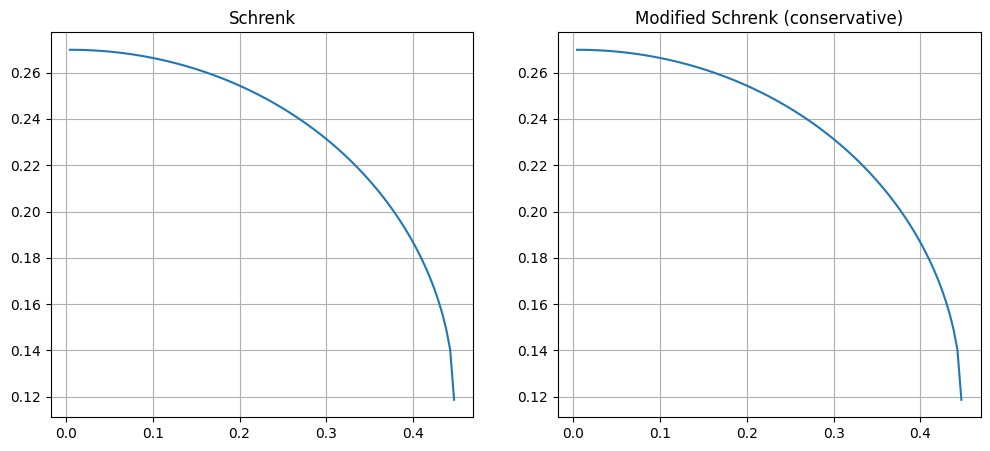

In [8]:
aircraft:list[Aircraft] = list()

for i, planform_recovered in enumerate(plaforms_recovered):
    main_wing = planform_recovered[0]
    planform_type = planform_recovered[1]

    ef = TailFinder(fixed, material=material_skin, core_density=assumptions.foam_denisty, thicknesses=assumptions.allowable_thicknesses, safety_factor=assumptions.structural_safety_factor, AR_h=max(4., main_wing.aspect_ratio/2)) if (planform_type == "tail") else CanardFinder(fixed, material=material_skin, core_density=assumptions.foam_denisty, thicknesses=assumptions.allowable_thicknesses, safety_factor=assumptions.structural_safety_factor, AR_c=max(5., main_wing.aspect_ratio/2))
    
    emp = ef.find_planforms(main_wing, print_=i==28)

    for e in emp:
        e.add_cache_entry("go_around", assumptions.airspeed_approach/asb.Atmosphere(assumptions.altitude_go_round).speed_of_sound(), assumptions.altitude_go_round)
        e.add_cache_entry("mach_max", assumptions.mach_max, assumptions.altitude_mach_max)
        e.add_cache_entry("cruise", assumptions.mach_cruise, assumptions.altitude_cruise)
        e.add_cache_entry("takeoff", assumptions.airspeed_approach/asb.Atmosphere().speed_of_sound(), 0.)
        e.mass_cache = 1
        e.x_cg_cache = .1

    aircraft_planforms = [main_wing] + emp #TODO add the empenage
    aircraft.append(Aircraft(
        fixed=fixed, #TODO: add the fuselage from CAD
        planforms=aircraft_planforms 
    ))

In [ ]:
s_ratios = [ac.planforms[1].wing_area / ac.planforms[0].wing_area for ac in aircraft]
print(s_ratios)
print(min(s_ratios), np.average(s_ratios), max(s_ratios))
ac_bad:Aircraft = aircraft[np.argmax(s_ratios)],
print(np.argmax(s_ratios))
ac_bad= ac_bad[0]
print(ac_bad.planforms[0].sweep_quarter_rad, ac_bad.planforms[0].aspect_ratio, ac_bad.planforms[0].cm_quarter_chord, ac_bad.planforms[0].thickness_to_chord)

[0.4156425644634447, 0.3883429056074242, 0.2837218019548506, 0.2599192498170163, 0.7499657151000741, 0.6068064569786635, 0.6100944133539344, 0.47599211989818985, 0.41500833848390595, 0.38771616911895285, 0.2830682915497295, 0.2592927811588813, 0.7492215572400029, 0.6060844940267962, 0.6093194589807868, 0.4752866354400148, 0.41434666935192876, 0.38706241059838403, 0.28238649403341476, 0.2586393035289437, 0.7484451154488717, 0.6053314941818111, 0.6085108982860398, 0.4745508311369066, 0.2703338255086363, 0.29457634564276897, 0.18535497352352487, 0.19898174598459645, 0.7075461021381886, 0.5874580971919111, 0.6135084427199521, 0.4967949366836375, 0.2753206826826789, 0.30024650461187846, 0.19044664422903224, 0.20464896213084557, 0.7140396036676155, 0.593898289126938, 0.6201835194307725, 0.5031353024656604, 0.2774722368687302, 0.30269493949959125, 0.19264311905611378, 0.20709616081763338, 0.7168391654573648, 0.5966812809780623, 0.6230615397040097, 0.5058752924941149, 0.11645408956821977, 0.13

# Checking if reuirements are met

In [ ]:
requirements:list[Requirement] = [
    MassReq(50.),
    MDReq(),
    FuelReq(),
    LGReq(),
    EmpennageReq(),
]

requirement_labels = [
    "MTOM",
    "Matching Diagram",
    "Fuel",
    "Landing Gear",
    "Empennage Requirement"
]

In [ ]:
for ac in aircraft:
    failed_reqs = list()
    for requirement, label in zip(requirements, requirement_labels):
        if not requirement.assess(ac):
            failed_reqs.append(label)

    if len(failed_reqs):
        print(f"ac mass: {ac.total_mass()}, {ac.planforms[0].oswald}")
        print(f"MainWing: AR={ac.planforms[0].aspect_ratio}, tc={ac.planforms[0].thickness_to_chord}, sweep={np.rad2deg(ac.planforms[0].sweep_quarter_rad)} deg, cmac={ac.planforms[0].cm_quarter_chord}")
        print(f"Failed: {failed_reqs}")
        print()

Fuel available: 11.000000001437996 kg
Fuel required: 7.08500302941312 kg
Difference: 3.914996972024876 kg
theta fails
ac mass: 40.1135418767164, 0.8140484418814391
MainWing: AR=5.0, tc=0.06, sweep=-10.0 deg, cmac=-0.15
Failed: ['Landing Gear', 'Empennage Requirement']

Fuel available: 11.000000001437996 kg
Fuel required: 7.145568574910729 kg
Difference: 3.8544314265272677 kg
theta fails
ac mass: 40.1135418767164, 0.8140484418814391
MainWing: AR=5.0, tc=0.06, sweep=-10.0 deg, cmac=-0.15
Failed: ['Landing Gear']

Fuel available: 11.000000001437996 kg
Fuel required: 7.183644538511226 kg
Difference: 3.8163554629267704 kg
theta fails
ac mass: 40.1135418767164, 0.8140484418814391
MainWing: AR=5.0, tc=0.06, sweep=-10.0 deg, cmac=0.1
Failed: ['Landing Gear']

Fuel available: 11.000000001437996 kg
Fuel required: 7.188686541949627 kg
Difference: 3.8113134594883693 kg
theta fails
ac mass: 40.1135418767164, 0.8140484418814391
MainWing: AR=5.0, tc=0.06, sweep=-10.0 deg, cmac=0.1
Failed: ['Landing G